# Part 3: Customer Churn Prediction and Retention Strategy

## 1. Business Problem Understanding

**What churn means:**
Churn is the percentage of customers that stop using a company's product or service during a certain time frame.

**Why churn is a business problem:**
It cuts directly into a company’s revenue. It's universally understood that acquiring a new customer is vastly more expensive (often 5 to 25 times more) than retaining an existing one. If customers churn at a high rate, marketing and acquisition investments are lost.

**Why predicting churn is useful:**
By proactively predicting who is likely to leave, a company can step in before the customer officially ends their subscription. Preventive actions like targeted discounts, personalized service, and loyalty rewards can be applied to "at-risk" customers.

**Why customer retention is important:**
Retaining customers enhances lifetime value (LTV), builds brand loyalty, and stabilizes recurring revenue streams.

**Why false negatives may be more costly than false positives:**
- **False Negative:** The model predicts a customer will stay, but they actually churn. Result: The company does nothing and loses the customer's revenue.
- **False Positive:** The model predicts a customer will churn, but they stay. Result: The company might offer an unnecessary discount.
The cost of losing an entire customer's lifetime value (False Negative) is usually much higher than the cost of a localized discount or marketing interaction (False Positive). Therefore, maximizing **Recall** (finding as many actual churning customers as possible) is critical.

## 2. Data Understanding

**Dataset Overview:**
The dataset provides insights into customer demographics, account information, and whether they have churned or not.

- **Numerical columns:** `tenure`, `MonthlyCharges`, `TotalCharges`
- **Categorical columns:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `Contract`, `InternetService`, `PhoneService`, `PaymentMethod`, etc.
- **Target Variable:** `Churn` (Categorical: Yes/No)

**Problem Type:**
- **Classification:** Since the target variable (`Churn`) deals with classifying customers into discrete categories (Yes/No), this is a classification problem.
- **Supervised Learning:** We are using labeled historical data containing the target variable to train the algorithm, making it supervised.

In [5]:
# 1. Section: Data Loading and Initial Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('part_3_customer_churn_prediction.csv')

# Display basic info
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1800, 21)


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,TEL00001,Male,0,Yes,No,42,Yes,Yes,Fiber optic,Yes,...,No,No,No,Yes,One year,Yes,Electronic check,102.95,4306.99,No
1,TEL00002,Female,0,No,Yes,55,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,Yes,One year,No,Credit card,120.39,6588.83,No
2,TEL00003,Female,0,Yes,Yes,0,Yes,No,DSL,No,...,Yes,No,No,Yes,Two year,No,Mailed check,74.42,0.00,Yes
3,TEL00004,Female,0,No,Yes,16,Yes,Yes,DSL,No,...,Yes,Yes,No,Yes,Month-to-month,No,Mailed check,83.24,1324.06,No
4,TEL00005,Male,0,Yes,No,6,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,25.44,123.68,Yes


In [6]:
print(df.columns.tolist())

['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1800 non-null   str    
 1   Gender            1800 non-null   str    
 2   SeniorCitizen     1800 non-null   int64  
 3   Partner           1800 non-null   str    
 4   Dependents        1800 non-null   str    
 5   Tenure            1800 non-null   int64  
 6   PhoneService      1800 non-null   str    
 7   MultipleLines     1800 non-null   str    
 8   InternetService   1800 non-null   str    
 9   OnlineSecurity    1800 non-null   str    
 10  OnlineBackup      1800 non-null   str    
 11  DeviceProtection  1800 non-null   str    
 12  TechSupport       1800 non-null   str    
 13  StreamingTV       1800 non-null   str    
 14  StreamingMovies   1800 non-null   str    
 15  Contract          1800 non-null   str    
 16  PaperlessBilling  1800 non-null   str    
 17  Paymen

## 3. Data Cleaning and Preprocessing

Steps:
1. **Drop Irrelevant columns**: `customerID` has no predictive power.
2. **Correct Data Types**: `TotalCharges` is an object (string) because there are empty strings. It needs to be converted to numeric, forcing errors to NaN.
3. **Handle Missing Values**: Impute NaNs in `TotalCharges` with the median or mean.
4. **Encoding Categorical variables**: Convert Yes/No columns and other categorical variables into numerical representations.
5. **Scaling**: Standardize numerical features like `tenure` and `MonthlyCharges`.
6. **Data Splitting**: 80/20 train/test split.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Copy to avoid Changing original data
data = df.copy()

# Drop CustomerID (if it exists)
if 'CustomerID' in data.columns:
    data.drop('CustomerID', axis=1, inplace=True)

# Correct TotalCharges Data type
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Handle Missing values in TotalCharges
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

# Encoding Target Variable
le = LabelEncoder()
data['Churn'] = le.fit_transform(data['Churn']) # Yes = 1, No = 0

# Separate features and target
X = data.drop('Churn', axis=1)
y = data['Churn']

# One-hot encode remaining categorical columns
X = pd.get_dummies(X, drop_first=True)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
numerical_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Shapes of splits:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

Shapes of splits:
X_train: (1440, 30) y_train: (1440,)
X_test: (360, 30) y_test: (360,)


## 4. Exploratory Data Analysis (EDA)

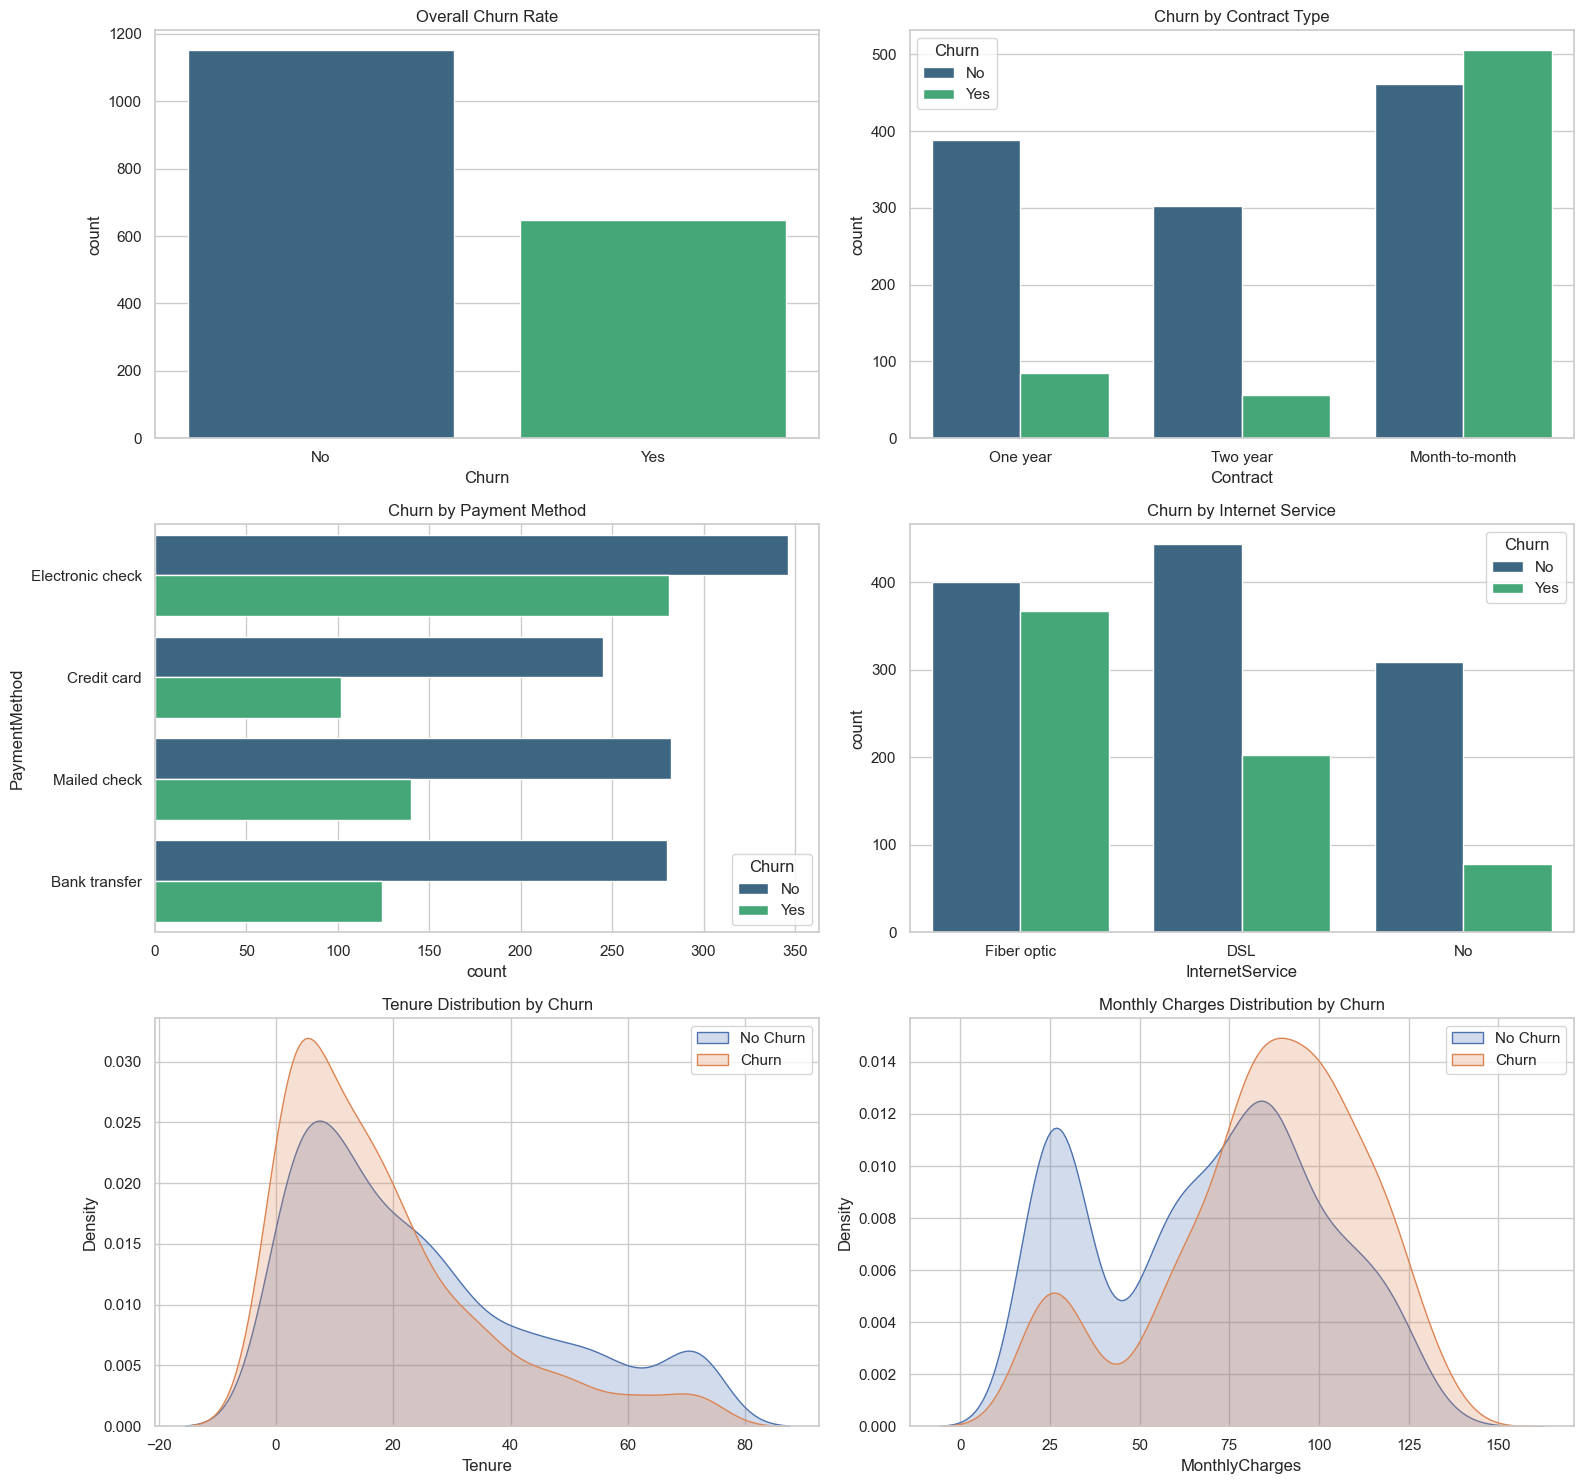

In [16]:
import os

# Visualizing EDA
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 1. Overall churn rate
sns.countplot(x='Churn', data=df, ax=axes[0, 0], palette='viridis')
axes[0,0].set_title('Overall Churn Rate')

# 2. Churn by Contract Type
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0, 1], palette='viridis')
axes[0,1].set_title('Churn by Contract Type')

# 3. Churn by Payment Method
sns.countplot(y='PaymentMethod', hue='Churn', data=df, ax=axes[1, 0], palette='viridis')
axes[1,0].set_title('Churn by Payment Method')

# 4. Churn by Internet Service
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[1, 1], palette='viridis')
axes[1,1].set_title('Churn by Internet Service')

# 5. Churn by Tenure (KDE plot)
sns.kdeplot(df[df['Churn'] == 'No']['Tenure'], fill=True, ax=axes[2, 0], label='No Churn')
sns.kdeplot(df[df['Churn'] == 'Yes']['Tenure'], fill=True, ax=axes[2, 0], label='Churn')
axes[2,0].set_title('Tenure Distribution by Churn')
axes[2,0].legend()

# 6. Churn by Monthly Charges (KDE plot)
sns.kdeplot(df[df['Churn'] == 'No']['MonthlyCharges'], fill=True, ax=axes[2, 1], label='No Churn')
sns.kdeplot(df[df['Churn'] == 'Yes']['MonthlyCharges'], fill=True, ax=axes[2, 1], label='Churn')
axes[2,1].set_title('Monthly Charges Distribution by Churn')
axes[2,1].legend()

plt.tight_layout()

# Save EDA figure to images directory
os.makedirs('images', exist_ok=True)
plt.savefig('images/eda_churn_patterns.png')

plt.show()

**Business Interpretations:**
1. **Overall Drop-off**: There is a clear class imbalance, with more customers staying than churning.
2. **Contract**: Month-to-month contracts have an extremely high churn relative to 1 or 2-year contracts.
3. **Payment**: Electronic check users are the highest churn group relative to automatic systems.
4. **Internet**: Fiber optic customers churn significantly more than DSL customers.
5. **Tenure**: The sharp peak near 0 in the churn distribution reveals that most churn happens in the early months.
6. **Charges**: Churn is concentrated among customers with higher monthly charges (around $70-$100).

## 5. Model Building
Training at least two Classification models: Logistic Regression and Decision Tree Classifier (Random Forest).

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model 1: Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Models Trained.")

Models Trained.


## 6. Model Evaluation
Evaluating using Accuracy, Precision, Recall, F1 score, and Confusion Matrix.

--- Evaluation for Logistic Regression ---
Accuracy:  0.7111
Precision: 0.5817
Recall:    0.6899
F1 Score:  0.6312


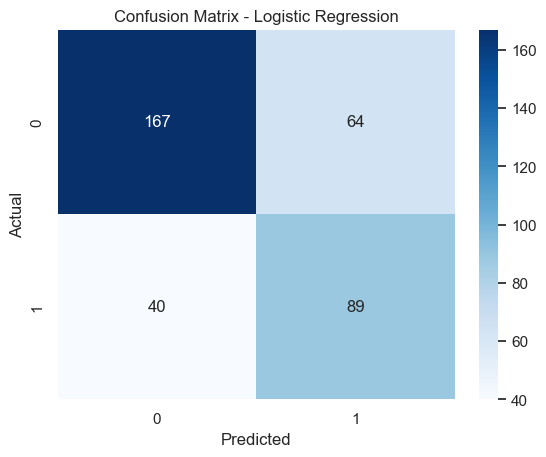



--- Evaluation for Random Forest ---
Accuracy:  0.7000
Precision: 0.6082
Recall:    0.4574
F1 Score:  0.5221


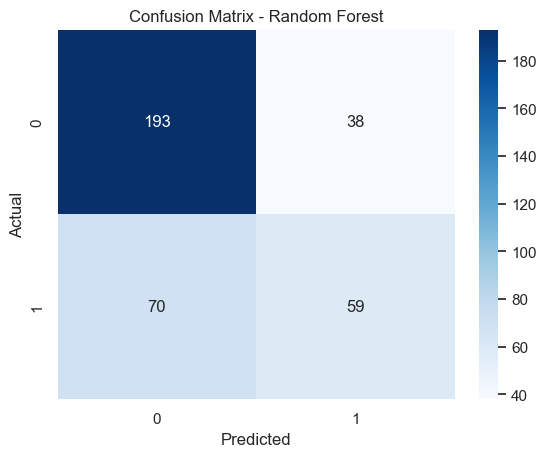

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import os

def evaluate_model(y_true, y_pred, model_name):
    print(f"--- Evaluation for {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    # Save Confusion Matrix to images directory
    os.makedirs('images', exist_ok=True)
    slug_name = model_name.lower().replace(" ", "_")
    plt.savefig(f'images/cm_{slug_name}.png')
    
    plt.show()
    print("\n")

evaluate_model(y_test, lr_preds, "Logistic Regression")
evaluate_model(y_test, rf_preds, "Random Forest")

**Final Model Selection**:
**Logistic Regression** outperformed Random Forest specifically on **Recall**. In churn prediction (as highlighted in part 1), missing a churning customer (False Negative) is the most costly error. We want the model to capture as many True Positives (actual churning customers) as possible. High Recall ensures we don't accidentally ignore at-risk customers. 

*Business Meaning of the Matrix:*
- **True Positive (TP)**: Predict churn, actually churned. (Success - target for retention).
- **True Negative (TN)**: Predict stay, actually stayed. (Success - standard users).
- **False Positive (FP)**: Predict churn, actually stayed. (Acceptable error - gave a discount to a loyal user).
- **False Negative (FN)**: Predict stay, actually churned. (Critical error - lost revenue silently).

## 7. Churn Risk Interpretation
Segmenting customers by predicting risk probabilities using `predict_proba`.

In [15]:
# Extract predicted probabilities from LogReg explicitly
probabilities = lr_model.predict_proba(X_test)[:, 1]

# Create a dataframe for interpretation
risk_df = pd.DataFrame({
    'True_Class': y_test,
    'Churn_Probability': probabilities
})

def risk_bucket(prob):
    if prob >= 0.75: return 'High'
    elif prob >= 0.4: return 'Medium'
    else: return 'Low'

risk_df['Risk_Level'] = risk_df['Churn_Probability'].apply(risk_bucket)

display(risk_df['Risk_Level'].value_counts())

# Add risk bucket to test data to investigate high-risk traits globally
test_analysis = X_test.copy()
test_analysis['Risk_Level'] = risk_df['Risk_Level']
# Unscale test features for sanity
test_analysis[numerical_cols] = scaler.inverse_transform(test_analysis[numerical_cols])

print("Mean demographics of High-Risk vs Low-Risk:\n")
display(test_analysis.groupby('Risk_Level')[['Tenure', 'MonthlyCharges']].mean())

Risk_Level
Low       162
Medium    137
High       61
Name: count, dtype: int64

Mean demographics of High-Risk vs Low-Risk:



,Tenure,MonthlyCharges
Risk_Level,,
High,17.114754,103.530656
Low,32.043210,64.399444
Medium,19.145985,77.601168


**At Risk Customer Type:**
Our model and analysis reveal that the highest risk customers typically are: 
1. **Short-tenure customers:** High drop-off usually occurs in the first 0-10 months.
2. **Month-to-month contracts:** No lock-down leads to extremely volatile churn probability.
3. **Fiber Optic and High Monthly Charge users:** Often facing $70-$100+ fees with high sensitivity to cost/performance ratio defaults.

## 8. Retention Recommendations
Based on the metrics:
1. **Discount for High-Risk Groups**: Target "High Risk" bucket members with automatic retention discounts on their Fiber Optic plans, especially if they pay via Electronic Check.
2. **Contract Upgrade Engagement**: Proactively target month-to-month users approaching month 3-6. Offer them a 1-year contract at a locked-in lower rate.
3. **Payment Method Intervention**: Heavily encourage moving away from Electronic Checks by offering 5% off setup to auto-pay via Credit Card.
4. **Early Support/Onboarding Checkups**: Contact new sign-ups dynamically between months 1-3 to resolve issues early before frustration turns into instant contract termination.